In [1]:
import sys
!{sys.executable} -m pip install opencv-python mtcnn tqdm pillow matplotlib tensorflow scikit-learn

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached mtcnn-1.0.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached mtcnn-1.0.0-py3-none-any.whl (1.9 MB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 2.1/350.6 MB 11.8 MB/s eta 0:00:30
    --------------------------------------- 4.7/350.6 MB 11.4 MB/s eta 0:00:31
    --------------------------------------- 6.8/350.6 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 9.4/350.6 MB 11.3 MB/s eta 0:00:31
   - -------------------------------------- 11.8/350.6 MB 11.4 MB/s eta 0:00:30
   - -------------------------------------- 14.2/350.6 MB 11.4 MB/s eta 0:00


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
from mtcnn import MTCNN
from tqdm import tqdm
import tensorflow as tf

print("cv2:", cv2.__version__)
print("TensorFlow:", tf.__version__)
print("Todo funcionando 🔥")

cv2: 4.13.0
TensorFlow: 2.21.0
Todo funcionando 🔥


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from mtcnn import MTCNN
from tqdm import tqdm

In [4]:
dataset_path = "dataset"
input_folder = os.path.join(dataset_path, "alumno1")
output_folder = os.path.join("dataset_procesado", "alumno1")

os.makedirs(output_folder, exist_ok=True)

print("Ruta de entrada:", input_folder)
print("Archivos en alumno1:", os.listdir(input_folder)[:10])

Ruta de entrada: dataset\alumno1
Archivos en alumno1: ['41EB0DFC-249A-4F62-9907-479610A80FA7.jpg', '5A4D4DAA-0189-401C-AD4A-3AC4E9847F80.jpg', '8384E120-55BC-4995-9E81-5C8C2A979464.jpg', '86666A23-B1BB-4BD8-A852-E6038DD6CAB9.jpg', 'CC16D70C-4C17-4AF7-B943-CA464938D32B.jpg', 'IMG_3978.jpg', 'IMG_6901.jpg', 'IMG_6902.jpg', 'IMG_7680.jpg', 'IMG_8124.jpg']


In [5]:
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".webp"):
            old_path = os.path.join(root, file)
            new_path = os.path.splitext(old_path)[0] + ".jpg"

            try:
                img = Image.open(old_path).convert("RGB")
                img.save(new_path, "JPEG")
                os.remove(old_path)
                print(f"Convertido: {old_path} -> {new_path}")
            except Exception as e:
                print(f"Error convirtiendo {old_path}: {e}")

print("Conversión terminada.")

Conversión terminada.


In [6]:
detector = MTCNN()

def extract_face(image_path, required_size=(160, 160)):
    image = cv2.imread(image_path)
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(image_rgb)

    if len(results) == 0:
        return None

    best_face = max(results, key=lambda x: x["confidence"])
    x, y, w, h = best_face["box"]

    x, y = abs(x), abs(y)
    face = image_rgb[y:y+h, x:x+w]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)
    return face

In [7]:
imagenes = os.listdir(input_folder)
guardadas = 0
omitidas = 0

for img_name in tqdm(imagenes, desc="Procesando alumno1"):
    img_path = os.path.join(input_folder, img_name)

    try:
        face = extract_face(img_path)

        if face is not None:
            save_path = os.path.join(output_folder, f"face_{guardadas}.jpg")
            cv2.imwrite(save_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
            guardadas += 1
        else:
            omitidas += 1

    except Exception as e:
        print(f"Error con {img_name}: {e}")
        omitidas += 1

print(f"Rostros guardados: {guardadas}")
print(f"Imágenes omitidas: {omitidas}")

Procesando alumno1: 100%|██████████| 10/10 [00:05<00:00,  1.92it/s]

Rostros guardados: 10
Imágenes omitidas: 0


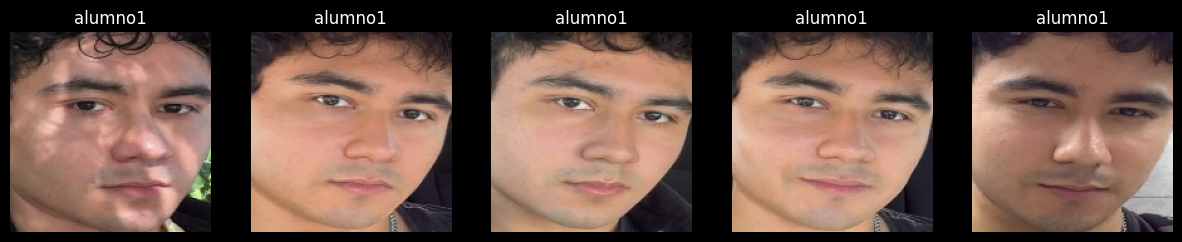

In [8]:
processed_images = os.listdir(output_folder)

if len(processed_images) == 0:
    print("No se procesó ninguna imagen.")
else:
    muestras = processed_images[:min(5, len(processed_images))]

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(muestras):
        img_path = os.path.join(output_folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(muestras), i + 1)
        plt.imshow(img)
        plt.title("alumno1")
        plt.axis("off")

    plt.show()

In [9]:
originales = len(os.listdir(input_folder))
procesadas = len(os.listdir(output_folder))

print("Imágenes originales:", originales)
print("Rostros procesados:", procesadas)

Imágenes originales: 10
Rostros procesados: 10
